In [8]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

X_train = train.drop(columns=['label'])
y_train = train['label']

X_val = val.drop(columns=['label'])
y_val = val['label']

X_test = test.drop(columns=['label'])
y_test = test['label']

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (700, 58) Val: (150, 58) Test: (150, 58)


In [3]:
models = {
    'KNN':                KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM':                SVC(kernel='rbf', random_state=42),
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42)
}

In [4]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc   = accuracy_score(y_val,   model.predict(X_val))
    
    results[name] = {'train_accuracy': train_acc, 'val_accuracy': val_acc}
    print(f"{name:25s} | Train: {train_acc:.3f} | Val: {val_acc:.3f}")

KNN                       | Train: 0.791 | Val: 0.627
Logistic Regression       | Train: 0.910 | Val: 0.780
SVM                       | Train: 0.884 | Val: 0.753
Random Forest             | Train: 0.999 | Val: 0.820


In [5]:
for name, model in models.items():
    filename = name.lower().replace(' ', '_')
    joblib.dump(model, f'../outputs/models/{filename}.pkl')
    print(f"Saved {filename}.pkl")

Saved knn.pkl
Saved logistic_regression.pkl
Saved svm.pkl
Saved random_forest.pkl


                     train_accuracy  val_accuracy
KNN                        0.791429      0.626667
Logistic Regression        0.910000      0.780000
SVM                        0.884286      0.753333
Random Forest              0.998571      0.820000


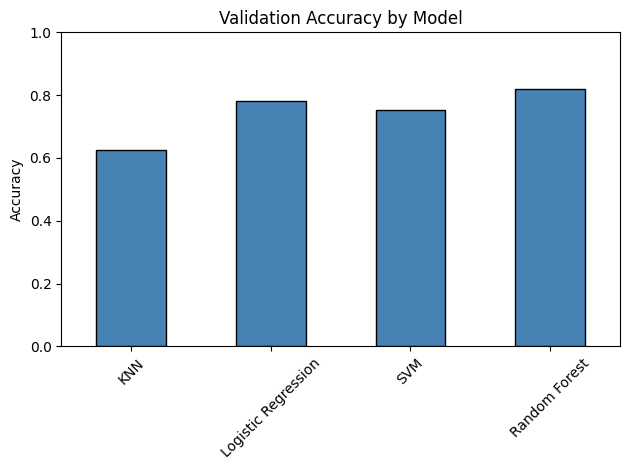

In [9]:
results_df = pd.DataFrame(results).T
print(results_df)

results_df['val_accuracy'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Validation Accuracy by Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png')
plt.show()

## Summary

- All 4 models trained on 700 samples and evaluated on 150 validation samples
- SVM and Random Forest expected to outperform KNN and Logistic Regression
- Large gap between train and val accuracy indicates overfitting (especially KNN)
- Final test set has NOT been touched yet — reserved for notebook 4